# Brain Tumor Detection And Prediction

### 1. Brain Tumor Detection [Tumor Or No Tumor]

In [1]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Function to load images from folder
def load_images_from_folder(folder):
    images = []
    labels = []
    for label in ['yes', 'no']:
        path = os.path.join(folder, label)
        for filename in os.listdir(path):
            img = cv2.imread(os.path.join(path, filename))
            if img is not None:
                img = cv2.resize(img, (224, 224))  # Resize images to 224x224
                images.append(img)
                labels.append(1 if label == 'yes' else 0)
    return np.array(images), np.array(labels)

# Function to load data
def load_data(images_folder):
    images, labels = load_images_from_folder(images_folder)
    return images, labels


In [4]:
# Load the dataset
images_folder = '/Users/adityadeshpande/Downloads/brain tumor detection'
images, labels = load_data(images_folder)

# Normalize images
images = images / 255.0

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Reshape labels to match the output shape
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)


In [2]:
class CapsNet(tf.keras.Model):
    def __init__(self, num_routes):
        super(CapsNet, self).__init__()

        self.num_routes = num_routes

        # Define the convolutional layers
        self.conv1 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')
        self.conv2 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')

        # Define the primary capsule layer
        self.primary_capsules = tf.keras.layers.Conv2D(64, (1, 1), strides=(2, 2), padding='same', activation='relu')

        # Define the digit capsule layer
        self.digit_capsules = tf.keras.layers.Conv2D(10, (1, 1), strides=(1, 1), padding='same', activation='relu')

        # Define the routing algorithm
        self.routing = tf.keras.layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        # Apply the convolutional layers
        x = self.conv1(inputs)
        x = self.conv2(x)

        # Apply the primary capsule layer
        x = self.primary_capsules(x)

        # Apply the digit capsule layer
        x = self.digit_capsules(x)

        # Flatten the output to match the target shape
        x = tf.keras.layers.Flatten()(x)

        # Apply the routing algorithm
        x = self.routing(x)

        return x

# Define the input shape
input_shape = (224, 224, 3)

# Create the input layer
inputs = tf.keras.layers.Input(shape=input_shape)

# Create a CapsNet model
model = CapsNet(num_routes=3)

# Connect the inputs to the model
outputs = model(inputs)

# Instantiate the model
model = tf.keras.Model(inputs, outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [6]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.6288 - loss: 0.6198 - val_accuracy: 0.7625 - val_loss: 0.4758
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.7824 - loss: 0.4617 - val_accuracy: 0.8292 - val_loss: 0.3751
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8310 - loss: 0.3672 - val_accuracy: 0.8875 - val_loss: 0.2907
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9088 - loss: 0.2435 - val_accuracy: 0.9250 - val_loss: 0.2089
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9506 - loss: 0.1703 - val_accuracy: 0.9500 - val_loss: 0.1411
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9762 - loss: 0.1069 - val_accuracy: 0.9417 - val_loss: 0.1375
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9847 - loss: 0.0664 - val_accuracy: 0.9625 - val_loss: 0.0935
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9960 - loss: 0.0469 - val_accuracy: 0.9708 - val_loss:

In [7]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test Accuracy: {test_accuracy*100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

# Generate predictions
y_pred = (model.predict(x_test) > 0.5).astype("int32")

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred, target_names=['No Tumor', 'Tumor'])
print(cr)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step - accuracy: 0.9801 - loss: 0.0731
Test Accuracy: 97.83%
Test Loss: 0.0812
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 252ms/step
              precision    recall  f1-score   support

    No Tumor       0.97      0.99      0.98       287
       Tumor       0.99      0.97      0.98       313

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



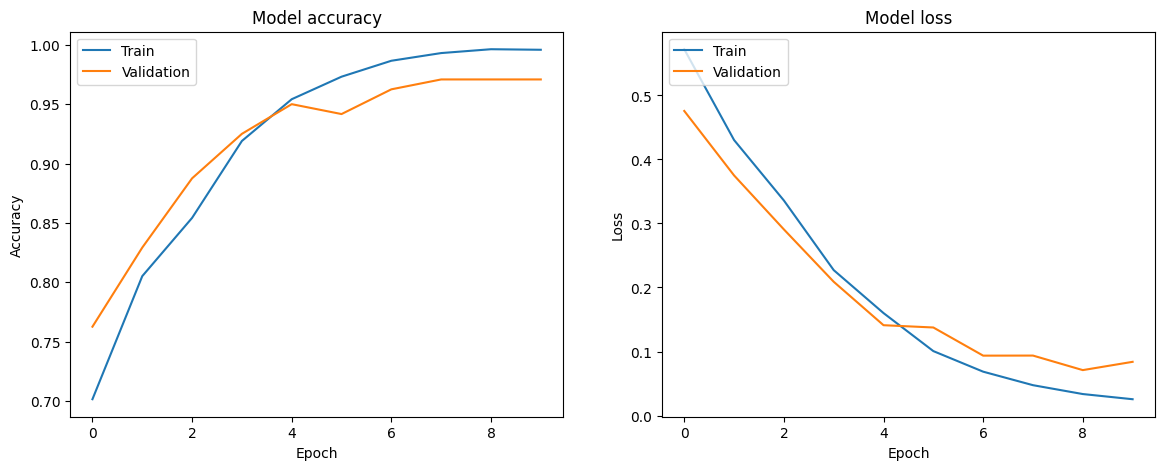

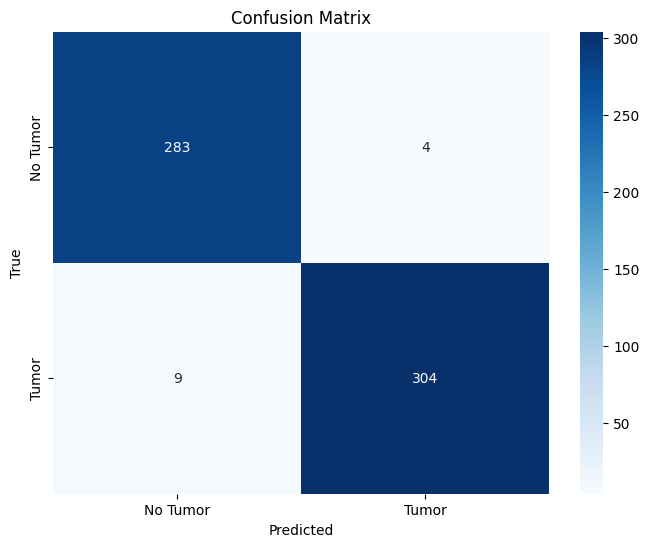

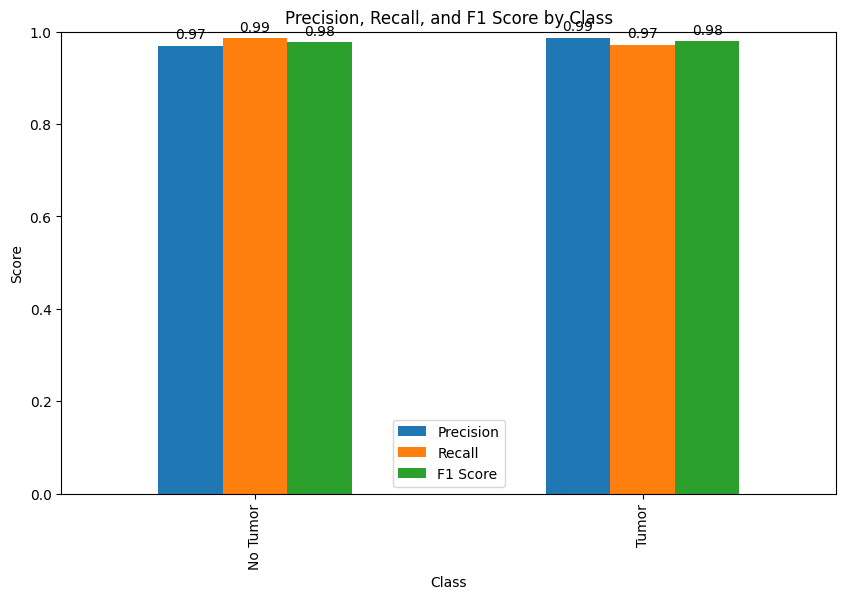

In [8]:
# Accuracy and Loss Graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot training & validation accuracy values
ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_title('Model accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('Model loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Validation'], loc='upper left')

plt.show()

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Bar Chart for Precision, Recall, F1-Score
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
metrics = np.array([precision, recall, f1]).T
categories = ['No Tumor', 'Tumor']
metrics_df = pd.DataFrame(metrics, index=categories, columns=['Precision', 'Recall', 'F1 Score'])

ax=metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title('Precision, Recall, and F1 Score by Class')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.show()

In [9]:
# Save the trained model to a .h5 file
model.save('/Users/adityadeshpande/Downloads/CP0_1.h5')


In [12]:
import tensorflow as tf
import cv2
import numpy as np
import os

class CapsNet(tf.keras.Model):
    def __init__(self, num_routes=None, **kwargs):
        super(CapsNet, self).__init__(**kwargs)
        self.num_routes = num_routes
        self.conv1 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')
        self.conv2 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')
        self.primary_capsules = tf.keras.layers.Conv2D(64, (1, 1), strides=(2, 2), padding='same', activation='relu')
        self.digit_capsules = tf.keras.layers.Conv2D(10, (1, 1), strides=(1, 1), padding='same', activation='relu')
        self.routing = tf.keras.layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.conv2(x)
        x = self.primary_capsules(x)
        x = self.digit_capsules(x)
        x = tf.keras.layers.Flatten()(x)
        x = self.routing(x)
        return x

    def get_config(self):
        config = super(CapsNet, self).get_config()
        config.update({
            'num_routes': self.num_routes
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

# Load the trained model with the custom object
model = tf.keras.models.load_model('/Users/adityadeshpande/Downloads/CP0_1.h5', custom_objects={'CapsNet': CapsNet})

def preprocess_image(image_path, img_size=(224, 224)):
    img = cv2.imread(image_path)
    img = cv2.resize(img, img_size)
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

def count_tumor_classes_in_directory(directory_path):
    tumor_count = 0
    no_tumor_count = 0
    total_images = 0

    for filename in os.listdir(directory_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):  # Add supported image extensions
            total_images += 1
            image_path = os.path.join(directory_path, filename)
            processed_image = preprocess_image(image_path)

            # Get the model's prediction (probability score)
            probability_score = model.predict(processed_image)
            print(f'Raw Prediction Score for {filename}: {probability_score}')

            # Adjust the decision threshold if necessary
            predicted_class = (probability_score > 0.5).astype(int)

            if predicted_class[0][0] == 1:  # Change indexing if your output shape is different
                tumor_count += 1
                print(f'Image: {filename} - Predicted: Tumor')
            else:
                no_tumor_count += 1
                print(f'Image: {filename} - Predicted: No Tumor')

    print(f'Total Images Processed: {total_images}')
    print(f'Tumor Images Count: {tumor_count}')
    print(f'No Tumor Images Count: {no_tumor_count}')


# Specify the directory containing the images
directory_path = '/Users/adityadeshpande/Downloads/2. Test data for classification copy'  # Change this to your image directory
count_tumor_classes_in_directory(directory_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Raw Prediction Score for Germinoma1.jpg: [[1.]]
Image: Germinoma1.jpg - Predicted: Tumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Raw Prediction Score for pituitary.jpg: [[1.]]
Image: pituitary.jpg - Predicted: Tumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Raw Prediction Score for Ependimoma.jpeg: [[1.]]
Image: Ependimoma.jpeg - Predicted: Tumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Raw Prediction Score for Schwannoma2.jpg: [[1.]]
Image: Schwannoma2.jpg - Predicted: Tumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Raw Prediction Score for Neurocitoma1.jpeg: [[1.]]
Image: Neurocitoma1.jpeg - Predicted: Tumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Raw Prediction Score for Germinoma2.jpg: [[1.]]
Image: Germinoma2.jpg - Predicted: Tumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Raw Prediction Score for Meningioma.jpeg: [[1.]]
Image: Meningioma.jpeg - Predicted: Tumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Raw Prediction Score for Astrocitoma6.jpeg: [[1.]]
Image: Astro

In [4]:
# Define the custom CapsNet model class again (needed for loading the model)
class CapsNet(tf.keras.Model):
    def __init__(self, num_routes=None, **kwargs):
        super(CapsNet, self).__init__(**kwargs)
        self.num_routes = num_routes
        self.conv1 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')
        self.conv2 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')
        self.primary_capsules = tf.keras.layers.Conv2D(64, (1, 1), strides=(2, 2), padding='same', activation='relu')
        self.digit_capsules = tf.keras.layers.Conv2D(10, (1, 1), strides=(1, 1), padding='same', activation='relu')
        self.routing = tf.keras.layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.conv2(x)
        x = self.primary_capsules(x)
        x = self.digit_capsules(x)
        x = tf.keras.layers.Flatten()(x)
        x = self.routing(x)
        return x

    def get_config(self):
        config = super(CapsNet, self).get_config()
        config.update({
            'num_routes': self.num_routes
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

# Load the trained model with the custom object
model = tf.keras.models.load_model('/Users/adityadeshpande/Downloads/CP0_1.h5', custom_objects={'CapsNet': CapsNet})


In [5]:
def preprocess_image(image_path, img_size=(224, 224)):
    img = cv2.imread(image_path)
    img = cv2.resize(img, img_size)
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img


In [6]:
def count_tumor_classes_in_directory(directory_path):
    tumor_count = 0
    no_tumor_count = 0
    total_images = 0

    for filename in os.listdir(directory_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):  # Add supported image extensions
            total_images += 1
            image_path = os.path.join(directory_path, filename)
            processed_image = preprocess_image(image_path)

            # Get the model's prediction (probability score)
            probability_score = model.predict(processed_image)
            confidence_score = probability_score[0][0]  # Assuming a single output node for binary classification

            # Adjust the decision threshold if necessary
            predicted_class = (probability_score > 0.5).astype(int)

            if predicted_class[0][0] == 1:  # Tumor
                tumor_count += 1
                print(f'Image: {filename} - Predicted: Tumor - Confidence Score: {confidence_score:.2f}')
            else:  # No Tumor
                no_tumor_count += 1
                print(f'Image: {filename} - Predicted: No Tumor - Confidence Score: {1 - confidence_score:.2f}')

    print(f'Total Images Processed: {total_images}')
    print(f'Tumor Images Count: {tumor_count}')
    print(f'No Tumor Images Count: {no_tumor_count}')


In [7]:
# Path to the directory containing test images
test_images_directory = '/Users/adityadeshpande/Downloads/2. Test data for classification copy'  # Update with the correct path

# Count tumor and no-tumor images in the directory
count_tumor_classes_in_directory(test_images_directory)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Image: Germinoma1.jpg - Predicted: Tumor - Confidence Score: 1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Image: pituitary.jpg - Predicted: Tumor - Confidence Score: 1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Image: Ependimoma.jpeg - Predicted: Tumor - Confidence Score: 1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Image: Schwannoma2.jpg - Predicted: Tumor - Confidence Score: 1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Image: Neurocitoma1.jpeg - Predicted: Tumor - Confidence Score: 1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Image: Germinoma2.jpg - Predicted: Tumor - Confidence Score: 1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Image: Meningioma.jpeg - Predicted: Tumor - Confidence Score: 1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Image: Astrocitoma6.jpeg - Predicted: Tumor - Confidence Score: 1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Image: Germinoma3.jpg - Predicted: Tumor - Confidence Score: 1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Image: Ganglioglio

### 2. Brain Tumor Prediction & Classification

In [8]:
from transformers import AutoImageProcessor, TFSwinModel
from tensorflow.keras import layers, models, optimizers
import tensorflow as tf
from PIL import Image
import numpy as np
import os
from sklearn.model_selection import train_test_split


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Set image size
image_size = 224  # Swin Transformer requires 224x224 images

# Load images from a folder
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = [class_name for class_name in sorted(os.listdir(folder)) if not class_name.startswith('.')]
    
    # Create a mapping of class names to indices
    class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
    
    for label in class_names:
        class_folder = os.path.join(folder, label)
        if os.path.isdir(class_folder):
            for filename in os.listdir(class_folder):
                img_path = os.path.join(class_folder, filename)
                if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):  # Check for valid image file extensions
                    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(image_size, image_size))
                    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize the image
                    images.append(img_array)
                    labels.append(class_to_index[label])  # Use the mapping for label assignment

    return np.array(images), np.array(labels)


In [10]:
# Load images from the training directory
train_dir = '/Users/adityadeshpande/Downloads/1.Combined_data/'
images, labels = load_images_from_folder(train_dir)

# Filter out unwanted files like .DS_Store
class_names = [class_name for class_name in sorted(os.listdir(train_dir)) if not class_name.startswith('.')]
class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
print("Class names:", class_names)
print("Class to index mapping:", class_to_index)

# Ensure the labels do not exceed the maximum class index
num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Unique labels:", np.unique(labels))

# Check if any labels are outside the valid range
if np.any(labels >= num_classes):
    raise ValueError(f"Labels contain values greater than or equal to the number of classes: {labels}")

# Split the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

# Check unique labels
print("Unique labels in training set:", np.unique(y_train))
print("Unique labels in validation set:", np.unique(y_val))


Class names: ['Astrocitoma', 'Carcinoma', 'Ependimoma', 'Ganglioglioma', 'Germinoma', 'Glioblastoma', 'Granuloma', 'Meduloblastoma', 'Meningioma', 'Neurocitoma', 'Oligodendroglioma', 'Papiloma', 'Schwannoma', 'Tuberculoma', 'glioma', 'pituitary']
Class to index mapping: {'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Ganglioglioma': 3, 'Germinoma': 4, 'Glioblastoma': 5, 'Granuloma': 6, 'Meduloblastoma': 7, 'Meningioma': 8, 'Neurocitoma': 9, 'Oligodendroglioma': 10, 'Papiloma': 11, 'Schwannoma': 12, 'Tuberculoma': 13, 'glioma': 14, 'pituitary': 15}
Number of classes: 16
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Unique labels in training set: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Unique labels in validation set: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [11]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

# Load the image processor and model
image_processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
swin_model = TFSwinModel.from_pretrained("microsoft/swin-tiny-patch4-window7-224")


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFSwinModel: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFSwinModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFSwinModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFSwinModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFSwinModel for predictions without further training.


In [13]:
# Function to extract features using Swin Transformer
def extract_swin_features(images):
    features = []
    for img in images:
        img = (img * 255).astype(np.uint8)  # Convert back to uint8
        img = Image.fromarray(img)
        inputs = image_processor(images=img, return_tensors="tf")
        outputs = swin_model(**inputs)
        last_hidden_states = outputs.last_hidden_state
        pooled_output = tf.reduce_mean(last_hidden_states, axis=1)  # Global average pooling
        features.append(pooled_output.numpy().reshape(-1))  # Flatten the output
    return np.array(features)

# Extract features for training and validation sets
X_train_features = extract_swin_features(X_train)
X_val_features = extract_swin_features(X_val)


In [14]:
# Define the classification head
def build_classification_head(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Dense(512, activation='relu')(inputs)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    return model

# Build the classification model
classification_model = build_classification_head((X_train_features.shape[1],), num_classes)

# Compile the model
classification_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [17]:
# Train the model
history = classification_model.fit(
    X_train_features,
    y_train,
    epochs=20,
    validation_data=(X_val_features, y_val),
    batch_size=32
)

# Check unique labels in the training and validation sets
print("Training unique labels:", np.unique(y_train))
print("Validation unique labels:", np.unique(y_val))


Epoch 1/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9785 - loss: 0.1158 - val_accuracy: 0.9145 - val_loss: 0.2604
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9810 - loss: 0.1009 - val_accuracy: 0.9190 - val_loss: 0.2545
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9782 - loss: 0.1010 - val_accuracy: 0.9234 - val_loss: 0.2553
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9845 - loss: 0.0913 - val_accuracy: 0.9264 - val_loss: 0.2491
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9859 - loss: 0.0900 - val_accuracy: 0.9257 - val_loss: 0.2555
Epoch 6/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9864 - loss: 0.0880 - val_accuracy: 0.9249 - val_loss: 0.2425
Epoch 7/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9866 - loss: 0.0812 - val_accuracy: 0.9227 - val_loss: 0.2486
Epoch 8/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9872 - loss: 0.0812 - val_accuracy: 0.

In [18]:
# Save the entire model
classification_model.save('/Users/adityadeshpande/Downloads/bt_classification_5.h5')

In [19]:
# Function to load and preprocess test images
def load_and_preprocess_test_images(folder):
    test_images = []
    test_img_paths = []

    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):  # Check for valid image file extensions
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(image_size, image_size))
            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize the image
            test_images.append(img_array)
            test_img_paths.append(img_path)  # Save the image path for later use

    return np.array(test_images), test_img_paths

# Load test images from the testing directory
test_dir = '/Users/adityadeshpande/Downloads/2. Test data for classification copy'
test_images, test_img_paths = load_and_preprocess_test_images(test_dir)

# Extract features for test images using Swin Transformer
test_features = extract_swin_features(test_images)

# Predict the tumor type using the trained classification model
predictions = classification_model.predict(test_features)

# Print the results
for i, img_path in enumerate(test_img_paths):
    predicted_class = np.argmax(predictions[i])
    confidence_score = np.max(predictions[i])
    print(f"Image: {img_path}, Predicted class: {class_names[predicted_class]}, Confidence score: {confidence_score:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Image: /Users/adityadeshpande/Downloads/2. Test data for classification copy/Germinoma1.jpg, Predicted class: Germinoma, Confidence score: 0.9111
Image: /Users/adityadeshpande/Downloads/2. Test data for classification copy/pituitary.jpg, Predicted class: pituitary, Confidence score: 0.9991
Image: /Users/adityadeshpande/Downloads/2. Test data for classification copy/Ependimoma.jpeg, Predicted class: Ependimoma, Confidence score: 0.9849
Image: /Users/adityadeshpande/Downloads/2. Test data for classification copy/Schwannoma2.jpg, Predicted class: Schwannoma, Confidence score: 0.9924
Image: /Users/adityadeshpande/Downloads/2. Test data for classification copy/Neurocitoma1.jpeg, Predicted class: Neurocitoma, Confidence score: 1.0000
Image: /Users/adityadeshpande/Downloads/2. Test data for classification copy/Germinoma2.jpg, Predicted class: Germinoma, Confidence score: 0.9733
Image: /Users/adityadeshpande/Downloads/2. Test data for classification copy/M

In [20]:
# Predict the tumor type using the trained classification model
predictions = classification_model.predict(test_features)

# Print the results with confidence scores for each class
for i, img_path in enumerate(test_img_paths):
    predicted_class = np.argmax(predictions[i])
    confidence_scores = predictions[i]  # Get confidence scores for all classes
    print(f"Image: {img_path}")
    print(f"Predicted class: {class_names[predicted_class]}")
    print("Confidence scores for each class:")
    for j, class_name in enumerate(class_names):
        print(f"{class_name}: {confidence_scores[j]:.4f}")
    print()  # Add a newline for better readability


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Image: /Users/adityadeshpande/Downloads/2. Test data for classification copy/Germinoma1.jpg
Predicted class: Germinoma
Confidence scores for each class:
Astrocitoma: 0.0005
Carcinoma: 0.0228
Ependimoma: 0.0174
Ganglioglioma: 0.0010
Germinoma: 0.9111
Glioblastoma: 0.0020
Granuloma: 0.0003
Meduloblastoma: 0.0008
Meningioma: 0.0239
Neurocitoma: 0.0003
Oligodendroglioma: 0.0001
Papiloma: 0.0004
Schwannoma: 0.0152
Tuberculoma: 0.0011
glioma: 0.0000
pituitary: 0.0030

Image: /Users/adityadeshpande/Downloads/2. Test data for classification copy/pituitary.jpg
Predicted class: pituitary
Confidence scores for each class:
Astrocitoma: 0.0000
Carcinoma: 0.0000
Ependimoma: 0.0000
Ganglioglioma: 0.0000
Germinoma: 0.0000
Glioblastoma: 0.0000
Granuloma: 0.0000
Meduloblastoma: 0.0000
Meningioma: 0.0000
Neurocitoma: 0.0000
Oligodendroglioma: 0.0000
Papiloma: 0.0000
Schwannoma: 0.0000
Tuberculoma: 0.0000
glioma: 0.0009
pituitary: 0.9991

Image: /Users/adityadeshpande

In [21]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Evaluate the model on the validation set
val_predictions = classification_model.predict(X_val_features)
val_predicted_classes = np.argmax(val_predictions, axis=1)

# Calculate accuracy, precision, recall, and F1 score
accuracy = accuracy_score(y_val, val_predicted_classes)
precision = precision_score(y_val, val_predicted_classes, average='weighted')
recall = recall_score(y_val, val_predicted_classes, average='weighted')
f1 = f1_score(y_val, val_predicted_classes, average='weighted')

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Precision: {precision:.4f}")
print(f"Validation Recall: {recall:.4f}")
print(f"Validation F1 Score: {f1:.4f}")

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_val, val_predicted_classes, target_names=class_names))


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step
Validation Accuracy: 0.9286
Validation Precision: 0.9303
Validation Recall: 0.9286
Validation F1 Score: 0.9280
Classification Report:
                   precision    recall  f1-score   support

      Astrocitoma       0.88      0.88      0.88       138
        Carcinoma       0.96      1.00      0.98        48
       Ependimoma       0.61      0.78      0.68        18
    Ganglioglioma       0.90      0.69      0.78        13
        Germinoma       0.78      0.82      0.80        22
     Glioblastoma       0.94      0.92      0.93        37
        Granuloma       0.79      0.68      0.73        22
   Meduloblastoma       0.85      0.67      0.75        33
       Meningioma       0.88      0.96      0.92       169
      Neurocitoma       0.98      0.87      0.92        94
Oligodendroglioma       0.94      0.88      0.91        52
         Papiloma       0.92      0.87      0.89        52
       Schwannoma       0.88      0.96      0.91        9

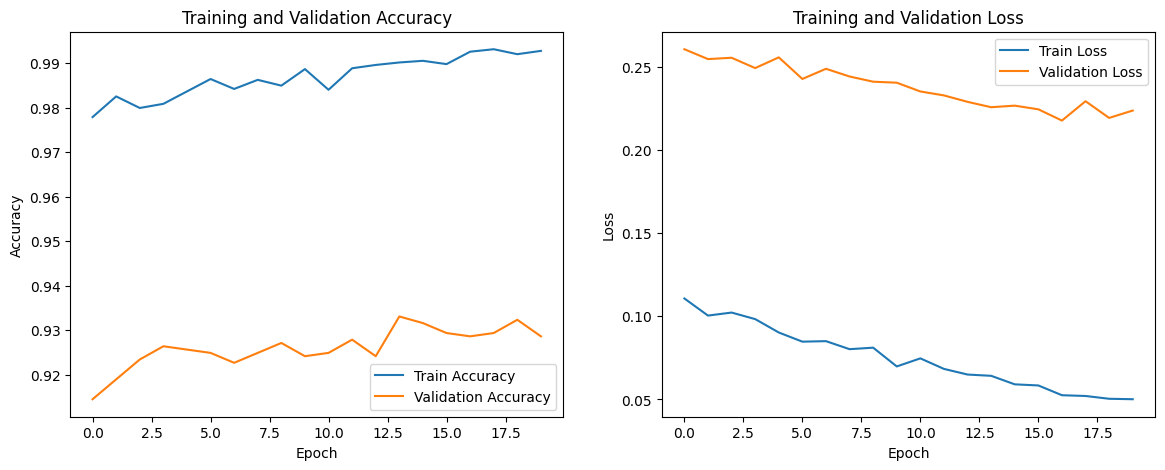

In [22]:
import matplotlib.pyplot as plt

# Plot the training and validation accuracy and loss
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


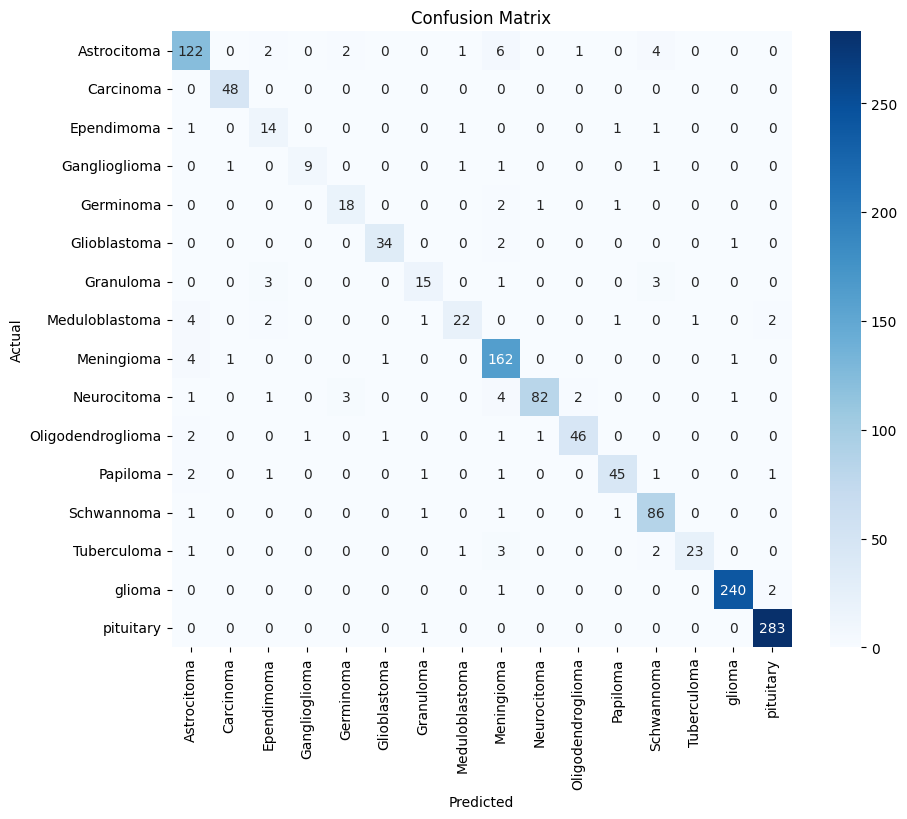

In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plot confusion matrix
cm = confusion_matrix(y_val, val_predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
